# Hartmann Benchmark Test

In [1]:
# Import necessary libraries
import sys
import warnings, os, torch, copy

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from optimpv import FitParam
    from optimpv.tests.Hartmann.HartmannAgent import *
    from optimpv.tests.Hartmann.HartmannModel import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import FitParam
    from optimpv.tests.Hartmann.HartmannAgent import *
    from optimpv.tests.Hartmann.HartmannModel import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer

plt.style.use('default')

## Benchmark Setup

This notebook uses the BoTorch Hartmann synthetic benchmark.

In [2]:
# Main notebook setup
hartmann_dim = 6  # supported: 3, 4, 6

total_evaluations = 60 #! * batch_size
n_init = 20
batch_size = 2

n_repeats = 5
seed_base = 1000

variations = [
    {'label': 'TuRBO-1 - TS', 'method': 'turbo', 'acq': 'ts'},
    {'label': 'TuRBO-1 - EI', 'method': 'turbo', 'acq': 'ei'},
    {'label': 'REI-TuRBO-1 - TS', 'method': 'reiturbo', 'acq': 'ts', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-1 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 1},
    {'label': 'REI-TuRBO-2 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 2},
    {'label': 'REI-TuRBO-4 - EI', 'method': 'reiturbo', 'acq': 'ei', 'n_trust_regions': 4},
]

print(f'Hartmann dimension: {hartmann_dim}D')
print(f'Total evaluations per variation: {total_evaluations * batch_size}')
print(f'Repeats per variation: {n_repeats}')
print(f'Seed base: {seed_base}')
print('Variations:')
for variation in variations:
    print('  -', variation['label'])

Hartmann dimension: 6D
Total evaluations per variation: 120
Repeats per variation: 5
Seed base: 1000
Variations:
  - TuRBO-1 - TS
  - TuRBO-1 - EI
  - REI-TuRBO-1 - TS
  - REI-TuRBO-1 - EI
  - REI-TuRBO-2 - EI
  - REI-TuRBO-4 - EI


In [3]:
# Build the Hartmann benchmark model and define the optimization parameters
hartmann_model = HartmannModel(dim=hartmann_dim)

params = []
for i in range(hartmann_model.nx):
    params.append(
        FitParam(
            name=f'x{i}',
            value=0.5,
            bounds=[0.0, 1.0],
            value_type='float',
            type='range',
            display_name=f'x{i}',
            axis_type='linear',
        )
    )

print(f'Dimension: {hartmann_model.nx}D')
print(f'Number of objectives: {hartmann_model.nf}')
print(f'Number of explicit constraints: {hartmann_model.ng}')
print(f'Initial midpoint objective: {hartmann_model.evaluate(np.full(hartmann_model.nx, 0.5))[0][0]:.6f}')

Dimension: 6D
Number of objectives: 1
Number of explicit constraints: 0
Initial midpoint objective: -0.505315


In [4]:
# Define the Agent and the target metric/loss function
hartmann_agent = HartmannAgent(
    params=params,
    dim=hartmann_dim,
    metric='obj',
    loss='linear',
    minimize=True,
    name='hartmann',
)

print('Agent metric name:', hartmann_agent.all_agent_metrics)

Agent metric name: ['hartmann_Hartmann6D_obj_linear']


In [5]:
import time

def build_optimizer(variation, seed=0):
    params_local = copy.deepcopy(params)
    agent_local = HartmannAgent(
        params=params_local,
        dim=hartmann_dim,
        metric='obj',
        loss='linear',
        minimize=True,
        name='hartmann',
    )

    if variation['method'] == 'turbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'TURBO']
    elif variation['method'] == 'reiturbo':
        model_kwargs_list = [
            {},
            {
                'torch_device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                'torch_dtype': torch.double,
                'acq': variation['acq'],
                'n_trust_regions': variation['n_trust_regions'],
                'region_init_points': 4,
                'racqf': 'REI',
                'seed': seed,
            },
        ]
        models = ['SOBOL', 'REITURBO']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params_local,
        agents=agent_local,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=False,
    )


def extract_history(optimizer):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    metric_name = df['metric_name'].iloc[0]
    hist = (
        df[df['metric_name'] == metric_name]
        .sort_values('trial_index')
        .loc[:, ['trial_index', 'mean']]
        .reset_index(drop=True)
    )
    hist['evaluation'] = np.arange(1, len(hist) + 1)
    hist['best_obj_val'] = hist['mean'].cummin()
    return hist, metric_name


def run_variation(variation, seed=0):
    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    runtime = time.time() - start_time
    history, metric_name = extract_history(optimizer)
    return {
        'label': variation['label'],
        'seed': seed,
        'history': history,
        'metric_name': metric_name,
        'runtime': runtime,
        'best_value': float(history['best_obj_val'].iloc[-1]),
    }


def combine_variation_runs(label, runs_for_label):
    merged = None
    for idx, run in enumerate(runs_for_label):
        hist = run['history'][['evaluation', 'best_obj_val']].copy()
        hist = hist.rename(columns={'best_obj_val': f'run_{idx}'})
        if merged is None:
            merged = hist
        else:
            merged = merged.merge(hist, on='evaluation', how='inner')

    run_cols = [col for col in merged.columns if col.startswith('run_')]
    merged['mean_best_obj_val'] = merged[run_cols].mean(axis=1)
    merged['std_best_obj_val'] = merged[run_cols].std(axis=1)

    return {
        'label': label,
        'history_mean': merged,
        'mean_best_obj_val': float(np.mean([run['best_value'] for run in runs_for_label])),
        'standard_deviation': float(np.std([run['best_value'] for run in runs_for_label])),
        'mean_runtime': float(np.mean([run['runtime'] for run in runs_for_label])),
        'runs': runs_for_label,
    }

## Run All Variations Repeatedly

In [6]:
all_runs = []
for variation in variations:
    for repeat_idx in range(n_repeats):
        current_seed = seed_base + repeat_idx
        print(f"Running {variation['label']} | repeat {repeat_idx + 1}/{n_repeats} | seed={current_seed}")
        all_runs.append(run_variation(variation, seed=current_seed))

combined_runs = []
for variation in variations:
    runs_for_label = [run for run in all_runs if run['label'] == variation['label']]
    combined_runs.append(combine_variation_runs(variation['label'], runs_for_label))

Running TuRBO-1 - TS | repeat 1/5 | seed=1000
Running TuRBO-1 - TS | repeat 2/5 | seed=1001
Running TuRBO-1 - TS | repeat 3/5 | seed=1002
Running TuRBO-1 - TS | repeat 4/5 | seed=1003
Running TuRBO-1 - TS | repeat 5/5 | seed=1004
Running TuRBO-1 - EI | repeat 1/5 | seed=1000
Running TuRBO-1 - EI | repeat 2/5 | seed=1001
Running TuRBO-1 - EI | repeat 3/5 | seed=1002
Running TuRBO-1 - EI | repeat 4/5 | seed=1003
Running TuRBO-1 - EI | repeat 5/5 | seed=1004
Running REI-TuRBO-1 - TS | repeat 1/5 | seed=1000
Running REI-TuRBO-1 - TS | repeat 2/5 | seed=1001
Running REI-TuRBO-1 - TS | repeat 3/5 | seed=1002
Running REI-TuRBO-1 - TS | repeat 4/5 | seed=1003
Running REI-TuRBO-1 - TS | repeat 5/5 | seed=1004
Running REI-TuRBO-1 - EI | repeat 1/5 | seed=1000
Running REI-TuRBO-1 - EI | repeat 2/5 | seed=1001
Running REI-TuRBO-1 - EI | repeat 3/5 | seed=1002
Running REI-TuRBO-1 - EI | repeat 4/5 | seed=1003
Running REI-TuRBO-1 - EI | repeat 5/5 | seed=1004
Running REI-TuRBO-2 - EI | repeat 1/5 | 

/home/lecorre/miniconda3/envs/testing/lib/python3.13/site-packages/botorch/optim/optimize.py:796: RuntimeWarning:

Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.



Running REI-TuRBO-4 - EI | repeat 5/5 | seed=1004


In [7]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'mean_runtime': run['mean_runtime'],
        'mean_best_obj_val': run['mean_best_obj_val'],
        'standard_deviation': run['standard_deviation'],
    }
    for run in combined_runs
).sort_values('mean_best_obj_val').reset_index(drop=True)

summary_df

,variation,mean_runtime,mean_best_obj_val,standard_deviation
0,TuRBO-1 - EI,15.651328,-3.298470,0.047691
1,TuRBO-1 - TS,6.433024,-3.274624,0.058386
2,REI-TuRBO-1 - TS,6.472287,-3.272328,0.057139
3,REI-TuRBO-2 - EI,23.975526,-3.250436,0.058484
4,REI-TuRBO-1 - EI,15.338381,-3.250327,0.058270
5,REI-TuRBO-4 - EI,23.888970,-3.035043,0.457418


## Mean Comparison Plot

Mean best objective values of each variation over the repeated runs, with standard deviation shading.

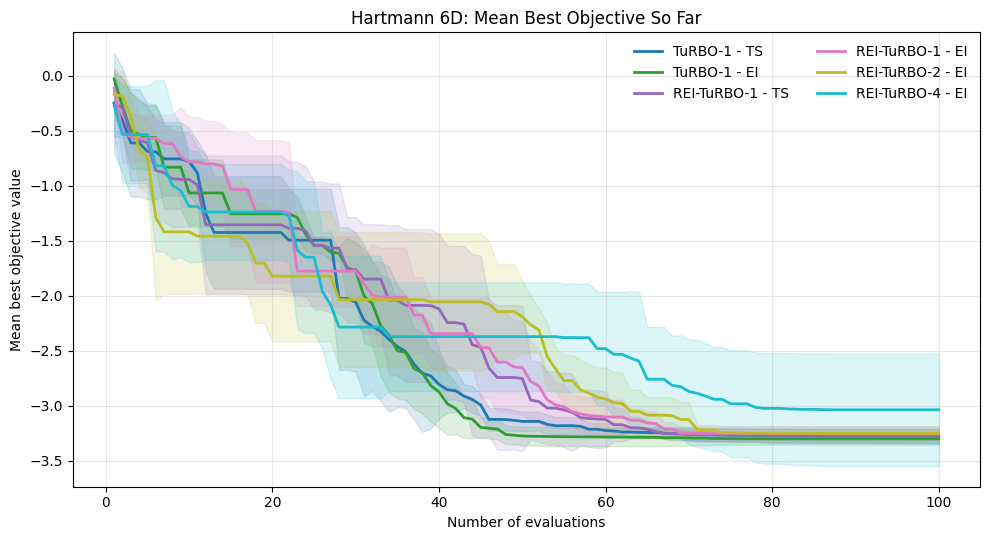

In [8]:
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(combined_runs)))

fig, ax = plt.subplots(figsize=(10, 5.5))

for color, run in zip(colors, combined_runs):
    hist = run['history_mean']
    mean_vals = hist['mean_best_obj_val']
    std_vals = hist['std_best_obj_val'].fillna(0.0)

    ax.plot(
        hist['evaluation'],
        mean_vals,
        color=color,
        lw=2.0,
        label=run['label'],
    )
    ax.fill_between(
        hist['evaluation'],
        mean_vals - std_vals,
        mean_vals + std_vals,
        color=color,
        alpha=0.15,
    )

ax.set_title(f'Hartmann {hartmann_dim}D: Mean Best Objective So Far')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Mean best objective value')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=False, ncol=2)

plt.tight_layout()
plt.show()